In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
df = pd.read_csv("/content/drive/MyDrive/Machine Learning/Unsupervised Learning/Clustering/customer_segmentation_K_mean_clustering/customer_segmentation.csv")

In [40]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [42]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [43]:
df.shape

(2240, 29)

In [44]:
df.isna().sum().sum()

np.int64(24)

In [45]:
df.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [46]:
df.dropna(inplace=True)

In [48]:
df.isna().sum().sum()

np.int64(0)

In [49]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [51]:
df['Education'].value_counts()

,count
Education,
Graduation,1116
PhD,481
Master,365
2n Cycle,200
Basic,54


In [52]:
df['Marital_Status'].value_counts()

,count
Marital_Status,
Married,857
Together,573
Single,471
Divorced,232
Widow,76
Alone,3
Absurd,2
YOLO,2


In [53]:
df['Dt_Customer'].value_counts()

,count
Dt_Customer,
31-08-2012,12
12-05-2014,11
14-02-2013,11
12-09-2012,11
22-05-2014,10
...,...
01-11-2013,1
10-08-2013,1
11-10-2012,1


In [54]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'],dayfirst=True)

In [55]:
df['Age'] = 2026 - df['Year_Birth']

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [58]:
df['Total_children'] = df['Kidhome'] + df['Teenhome']

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [61]:
spend_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']

In [62]:
df['Total_Spending'] = df[spend_cols].sum(axis=1)

In [63]:
df['Total_Spending']

,Total_Spending
0,1617
1,27
2,776
3,53
4,422
...,...
2235,1341
2236,444
2237,1241
2238,843


In [64]:
df['Customer_Since'] = (pd.Timestamp('today') - df['Dt_Customer']).dt.days

In [65]:
df['Customer_Since']

,Customer_Since
0,5137
1,4587
2,4786
3,4613
4,4635
...,...
2235,4855
2236,4493
2237,4629
2238,4630


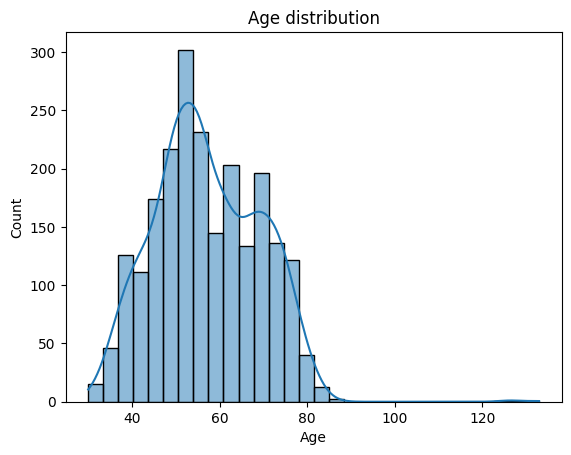

In [67]:
sns.histplot(df["Age"],bins=30,kde=True)
plt.title("Age distribution")
plt.show()

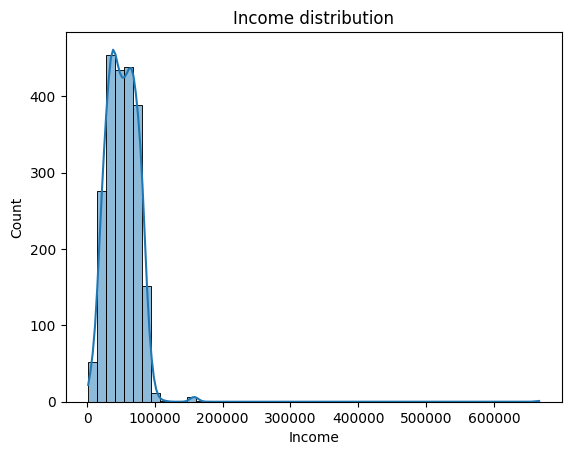

In [70]:
sns.histplot(df["Income"],bins=50,kde=True)
plt.title("Income distribution")
plt.show()

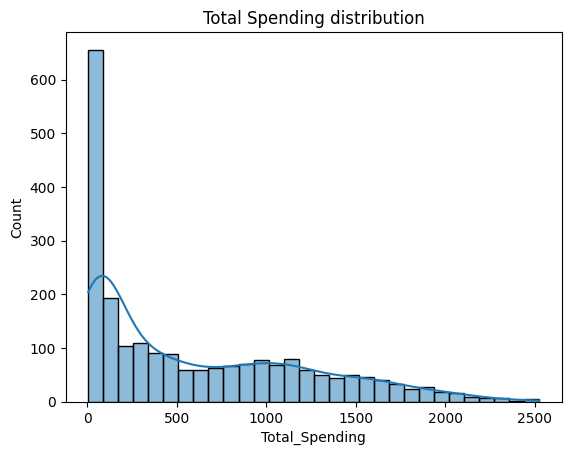

In [71]:
sns.histplot(df["Total_Spending"],bins=30,kde=True)
plt.title("Total Spending distribution")
plt.show()

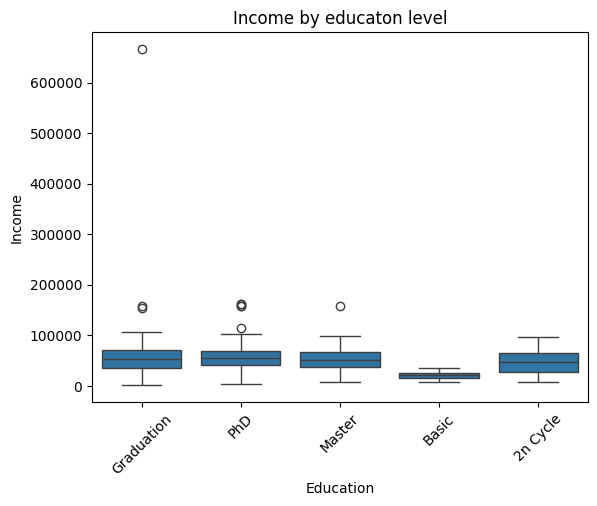

In [72]:
sns.boxplot(x='Education', y='Income', data=df)
plt.xticks(rotation=45)
plt.title("Income by educaton level")
plt.show()

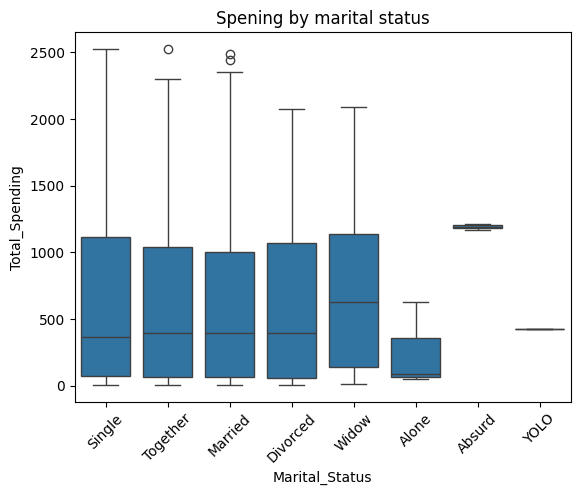

In [73]:
sns.boxplot(x='Marital_Status', y='Total_Spending', data=df)
plt.xticks(rotation=45)
plt.title("Spening by marital status")
plt.show()

In [77]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_children', 'Total_Spending', 'Customer_Since'],
      dtype='object')

In [80]:
corr = df[['Income','Age','Recency','Total_Spending','NumWebPurchases','NumStorePurchases']].corr()


In [81]:
corr

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases
Income,1.000000,0.161791,-0.003970,0.667576,0.387878,0.529362
Age,0.161791,1.000000,0.016295,0.113487,0.153051,0.127891
Recency,-0.003970,0.016295,1.000000,0.020066,-0.005641,-0.000434
Total_Spending,0.667576,0.113487,0.020066,1.000000,0.528973,0.675181
NumWebPurchases,0.387878,0.153051,-0.005641,0.528973,1.000000,0.516240
NumStorePurchases,0.529362,0.127891,-0.000434,0.675181,0.516240,1.000000


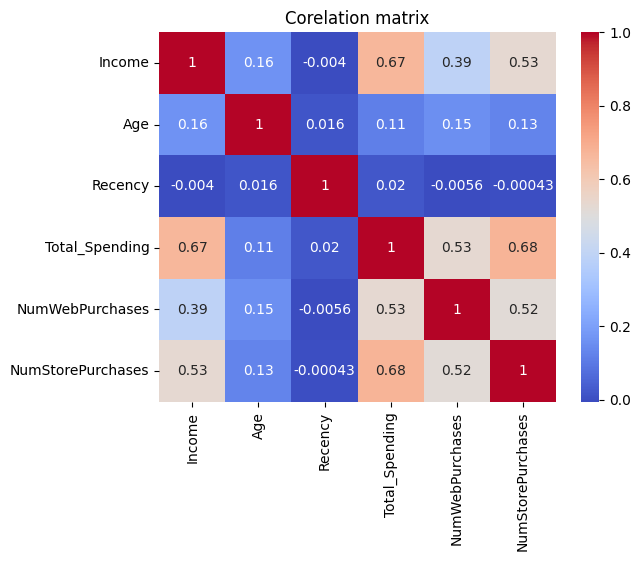

In [89]:
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Corelation matrix")
plt.show()

In [90]:
pivot_income = df.pivot_table(values='Income', index='Education', columns='Marital_Status', aggfunc='mean')

In [91]:
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46201.100000,53673.944444,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,56041.422414,60288.083333,48432.0


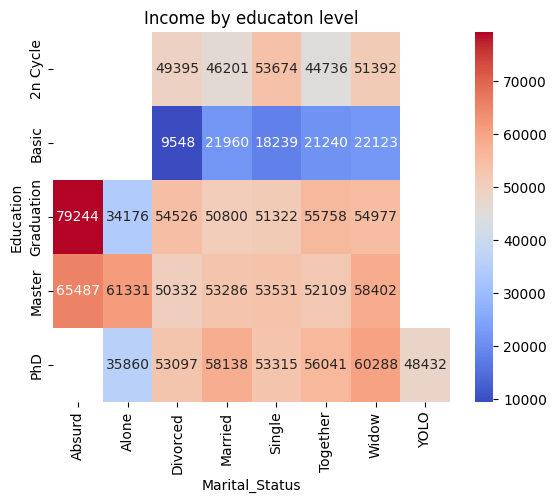

In [93]:
sns.heatmap(pivot_income,annot=True,cmap="coolwarm",fmt=".0f")
plt.title("Income by educaton level")
plt.show()


In [96]:
group1 = df.groupby("Education")["Total_Spending"].mean().sort_values(ascending=False)

In [97]:
group1

,Total_Spending
Education,
PhD,676.733888
Graduation,621.686380
Master,609.767123
2n Cycle,494.930000
Basic,81.796296


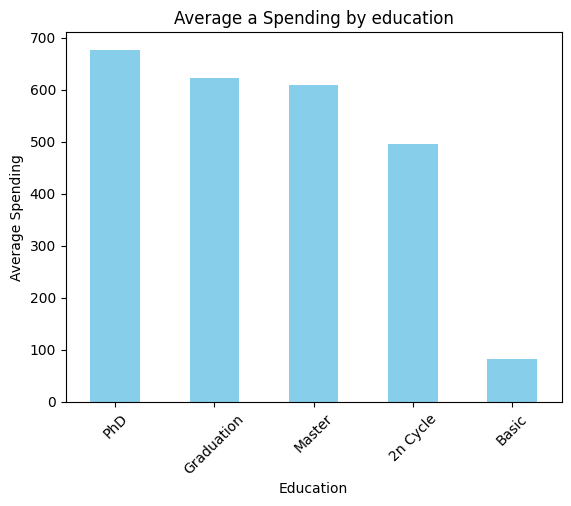

In [103]:
group1.plot(kind="bar",color="skyblue")
plt.title("Average a Spending by education")
plt.ylabel("Average Spending")
plt.xlabel("Education")
plt.xticks(rotation=45)
plt.show()

In [109]:
df['AcceptedAny'] = df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']].sum(axis=1)

In [110]:
df['AcceptedAny'].unique()

array([1, 0, 3, 2, 4, 5])

In [111]:
df['AcceptedAny'] = df['AcceptedAny'].apply(lambda x : 1 if x>0 else 0)

In [114]:
df['AcceptedAny'].unique()

array([1, 0])

In [115]:
group2 = df.groupby("Marital_Status")["AcceptedAny"].mean().sort_values(ascending=False)

In [116]:
group2

,AcceptedAny
Marital_Status,
Absurd,0.500000
YOLO,0.500000
Widow,0.342105
Alone,0.333333
Single,0.312102
Divorced,0.297414
Married,0.252042
Together,0.251309


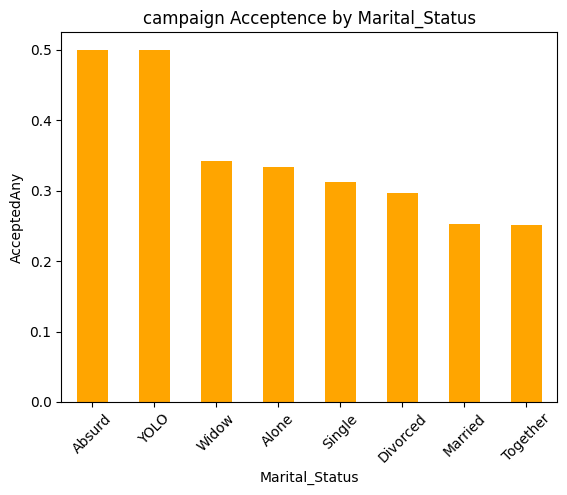

In [120]:
group2.plot(kind="bar",color="orange")
plt.title("campaign Acceptence by Marital_Status")
plt.ylabel("AcceptedAny")
plt.xlabel("Marital_Status")
plt.xticks(rotation=45)
plt.show()

In [121]:
bins = [18, 30, 40, 50, 60, 70, 90]

In [123]:
labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]

In [125]:
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [127]:
df["AgeGroup"].unique()

['60-69', '70+', '40-49', '50-59', '30-39', '18-29', NaN]
Categories (6, object): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70+']

In [128]:
group3= df.groupby("AgeGroup")["Income"].mean()

/tmp/ipykernel_5684/3195967181.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group3= df.groupby("AgeGroup")["Income"].mean()


In [129]:
group3

,Income
AgeGroup,
18-29,10960.500000
30-39,47905.475676
40-49,48057.587649
50-59,50479.321534
60-69,55980.030928
70+,58767.083102


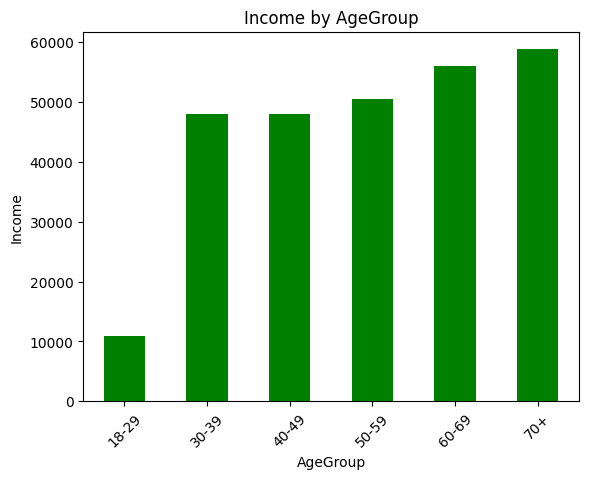

In [130]:
group3.plot(kind="bar", color="green")
plt.title("Income by AgeGroup")
plt.ylabel("Income")
plt.xlabel("AgeGroup")
plt.xticks(rotation=45)
plt.show()

In [131]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_children', 'Total_Spending', 'Customer_Since',
       'AcceptedAny', 'AgeGroup'],
      dtype='object')

In [136]:
features = ["Age","Income","Total_Spending","NumWebPurchases","NumStorePurchases","NumWebVisitsMonth","Recency"]

In [137]:
X = df[features].copy()

In [138]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [139]:
from sklearn.cluster import KMeans

In [140]:
wcss = []

In [141]:
for i in range(2,10):
  kmeans = KMeans(n_clusters=i)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)

In [142]:
wcss

[10218.620143748776,
 9007.786818672812,
 8159.286962872504,
 7568.49550352684,
 7198.561405408676,
 6718.381869643975,
 6454.203882551676,
 5894.191654027193]

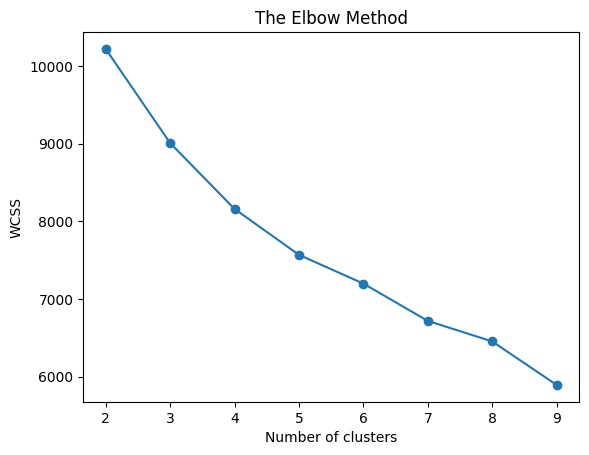

In [143]:
plt.plot(range(2,10), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [145]:
kmeans = KMeans(n_clusters=6)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [147]:
df['Cluster']

,Cluster
0,0
1,5
2,2
3,4
4,1
...,...
2235,0
2236,0
2237,3
2238,2


In [148]:
cluster_summary = df.groupby('Cluster')[features].mean()

In [149]:
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,61.022876,57983.591503,831.261438,8.248366,6.728758,6.604575,55.473856
1,52.391304,34230.608696,124.881643,2.362319,3.369565,6.698068,78.461353
2,60.337176,68172.040346,1081.233429,5.997118,10.253602,4.420749,30.334294
3,56.055825,79547.099515,1355.570388,4.245146,7.788835,2.208738,60.021845
4,49.318083,32090.385621,105.978214,2.150327,3.152505,6.784314,26.148148
5,70.784173,45708.158273,204.622302,2.640288,4.269784,5.161871,42.794964


In [151]:
df["Cluster"].value_counts()

,count
Cluster,
4,459
1,414
3,412
2,347
0,306
5,278
